<div style=" background-color: RGB(0,114,200);" >
<h1 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">PROJET 4 DATA ANALYST</h1>
<h2 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">Réalisez une étude de santé publique avec R ou Python
</h2>
</div>

# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner codes, textes et graphique.

Cet outil est formidable pour plusieurs raisons:

+ il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'un instruction, de la corriger si nécessaire.
+ De rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ d'agrémenter de graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandée.

Et garder à l'esprit, qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.1 - Importation des librairies</h3>
</div>

In [2]:
#Importation de la librairie Pandas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt    
import seaborn as sns

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.2 - Chargement des fichiers Excel</h3>
</div>

In [3]:
#Importation du fichier population.csv
population = pd.read_csv('population.csv')

#Importation du fichier dispo_alimentaire.csv
dispo_alimentaire = pd.read_csv('dispo_alimentaire.csv')

#Importation du fichier aide_alimentaire.csv
aide_alimentaire = pd.read_csv('aide_alimentaire.csv')

#Importation du fichier sous_nutrition.csv
sous_nutrition = pd.read_csv('sous_nutrition.csv')

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.1 - Analyse exploratoire du fichier population</h3>
</div>

In [4]:
#Afficher les dimensions du dataset
print("Le tableau population comporte {} observation(s) ou article(s)".format(population.shape[0]))
print("Le tableau population comporte {} colonne(s)".format(population.shape[1]))

Le tableau population comporte 1416 observation(s) ou article(s)
Le tableau population comporte 3 colonne(s)


In [5]:
#Consulter le nombre de colonnes
dim_population = population.shape
print("Le tableau comporte {} colonne(s).".format(dim_population[1]))
#La nature des données dans chacune des colonnes
print("Types des données de chaque colonne : {}".format(population.dtypes))
#Le nombre de valeurs présentes dans chacune des colonnes
print("Nombre de valeurs présentes dans chaque colonne :\n{}".format(population.count()))

Le tableau comporte 3 colonne(s).
Types des données de chaque colonne : Zone       object
Année       int64
Valeur    float64
dtype: object
Nombre de valeurs présentes dans chaque colonne :
Zone      1416
Année     1416
Valeur    1416
dtype: int64


In [6]:
#Affichage les 5 premières lignes de la table
population.head()

,Zone,Année,Valeur
0,Afghanistan,2013,32269.589
1,Afghanistan,2014,33370.794
2,Afghanistan,2015,34413.603
3,Afghanistan,2016,35383.032
4,Afghanistan,2017,36296.113


In [7]:
#Nous allons harmoniser les unités. Pour cela, nous avons décidé de multiplier la population par 1000
#Multiplication de la colonne valeur par 1000
population['Valeur'] = population['Valeur'] * 1000

In [8]:
#changement du nom de la colonne Valeur par Population
population = population.rename(columns = {'Valeur':'Population'})


In [9]:
#Affichage les 5 premières lignes de la table pour voir les modifications
population.head()

,Zone,Année,Population
0,Afghanistan,2013,32269589.0
1,Afghanistan,2014,33370794.0
2,Afghanistan,2015,34413603.0
3,Afghanistan,2016,35383032.0
4,Afghanistan,2017,36296113.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.2 - Analyse exploratoire du fichier disponibilité alimentaire</h3>
</div>

In [10]:
#Afficher les dimensions du dataset
print("Le tableau dispo_alimentaire comporte {} observation(s) ou article(s)".format(dispo_alimentaire.shape[0]))
print("Le tableau dispo_alimentaire comporte {} colonne(s)".format(dispo_alimentaire.shape[1]))

Le tableau dispo_alimentaire comporte 15605 observation(s) ou article(s)
Le tableau dispo_alimentaire comporte 18 colonne(s)


In [11]:
#Consulter le nombre de colonnes
dim_dispo = dispo_alimentaire.shape
print("Le tableau comporte {} colonnes".format(dim_dispo[1]))

Le tableau comporte 18 colonnes


In [12]:
#Affichage les 5 premières lignes de la table
dispo_alimentaire.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,NaN,NaN,5.0,1.72,0.20,0.77,53.0,NaN,NaN,53.0,NaN,53.0,NaN,NaN,NaN
1,Afghanistan,"Agrumes, Autres",vegetale,NaN,NaN,1.0,1.29,0.01,0.02,41.0,2.0,40.0,39.0,2.0,3.0,NaN,NaN,NaN
2,Afghanistan,Aliments pour enfants,vegetale,NaN,NaN,1.0,0.06,0.01,0.03,2.0,NaN,2.0,2.0,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,Ananas,vegetale,NaN,NaN,0.0,0.00,NaN,NaN,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,Bananes,vegetale,NaN,NaN,4.0,2.70,0.02,0.05,82.0,NaN,82.0,82.0,NaN,NaN,NaN,NaN,NaN


In [13]:
#remplacement des NaN dans le dataset par des 0
dispo_alimentaire = dispo_alimentaire.fillna(0)
dispo_alimentaire.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53.0,0.0,0.0,53.0,0.0,53.0,0.0,0.0,0.0
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41.0,2.0,40.0,39.0,2.0,3.0,0.0,0.0,0.0
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82.0,0.0,82.0,82.0,0.0,0.0,0.0,0.0,0.0


In [14]:
#multiplication de toutes les lignes contenant des milliers de tonnes en Kg
dispo_alimentaire.iloc[:, 3:5] = dispo_alimentaire.iloc[:, 3:5] * 1000000
dispo_alimentaire.iloc[:, 9:18] = dispo_alimentaire.iloc[:, 9:18] * 1000000


In [15]:
#Affichage les 5 premières lignes de la table
dispo_alimentaire.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53000000.0,0.0,0.0,53000000.0,0.0,53000000.0,0.0,0.0,0.0
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000000.0,2000000.0,40000000.0,39000000.0,2000000.0,3000000.0,0.0,0.0,0.0
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000000.0,0.0,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000000.0,0.0,82000000.0,82000000.0,0.0,0.0,0.0,0.0,0.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.3 - Analyse exploratoire du fichier aide alimentaire</h3>
</div>

In [16]:
#Afficher les dimensions du dataset
print("Le tableau aide_alimentaire comporte {} observation(s) ou article(s)".format(aide_alimentaire.shape[0]))
print("Le tableau aide_alimentaire comporte {} colonne(s)".format(aide_alimentaire.shape[1]))

Le tableau aide_alimentaire comporte 1475 observation(s) ou article(s)
Le tableau aide_alimentaire comporte 4 colonne(s)


In [17]:
#Consulter le nombre de colonnes
dim_aide_alim = aide_alimentaire.shape
print("Le tableau comporte {} colonne(s).".format(dim_aide_alim[1]))

Le tableau comporte 4 colonne(s).


In [18]:
#Affichage les 5 premières lignes de la table
aide_alimentaire.head()

,Pays bénéficiaire,Année,Produit,Valeur
0,Afghanistan,2013,Autres non-céréales,682
1,Afghanistan,2014,Autres non-céréales,335
2,Afghanistan,2013,Blé et Farin,39224
3,Afghanistan,2014,Blé et Farin,15160
4,Afghanistan,2013,Céréales,40504


In [19]:
#changement du nom de la colonne Pays bénéficiaire par Zone
aide_alimentaire = aide_alimentaire.rename(columns={'Pays bénéficiaire':'Zone'})

In [20]:
#Multiplication de la colonne Aide_alimentaire qui contient des tonnes par 1000 pour avoir des kg
aide_alimentaire['Valeur'] = aide_alimentaire['Valeur']*1000

In [21]:
#Affichage les 5 premières lignes de la table
aide_alimentaire.head(15)

,Zone,Année,Produit,Valeur
0,Afghanistan,2013,Autres non-céréales,682000
1,Afghanistan,2014,Autres non-céréales,335000
2,Afghanistan,2013,Blé et Farin,39224000
3,Afghanistan,2014,Blé et Farin,15160000
4,Afghanistan,2013,Céréales,40504000
5,Afghanistan,2014,Céréales,15989000
6,Afghanistan,2013,"Fruits secs, total",85000
7,Afghanistan,2013,Huiles végétales,11087000
8,Afghanistan,2014,Huiles végétales,8185000
9,Afghanistan,2013,"Légumineuses Sèches,Tot.",11761000


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.3 - Analyse exploratoire du fichier sous nutrition</h3>
</div>

In [22]:
#Afficher les dimensions du dataset
print("Le tableau sous_nutrition comporte {} observation(s) ou article(s)".format(sous_nutrition.shape[0]))
print("Le tableau sous_nutrition comporte {} colonne(s)".format(sous_nutrition.shape[1]))

Le tableau sous_nutrition comporte 1218 observation(s) ou article(s)
Le tableau sous_nutrition comporte 3 colonne(s)


In [23]:
#Consulter le nombre de colonnes
dim_sous_nutrition = sous_nutrition.shape
print("Le tableau comporte {} colonne(s).".format(dim_sous_nutrition[1]))

Le tableau comporte 3 colonne(s).


In [24]:
#Afficher les 5 premières lignes de la table
sous_nutrition.head()

,Zone,Année,Valeur
0,Afghanistan,2012-2014,8.6
1,Afghanistan,2013-2015,8.8
2,Afghanistan,2014-2016,8.9
3,Afghanistan,2015-2017,9.7
4,Afghanistan,2016-2018,10.5


In [25]:
#Conversion de la colonne sous nutrition en numérique
#sous_nutrition['Valeur'] = pd.to_numeric(sous_nutrition['Valeur'])

In [26]:
#Conversion de la colonne (avec l'argument errors=coerce qui permet de convertir automatiquement les lignes qui ne sont pas des nombres en NaN)
sous_nutrition['Valeur'] = pd.to_numeric(sous_nutrition['Valeur'], errors='coerce')

#Puis remplacement des NaN en 0
sous_nutrition = sous_nutrition.fillna(0)

In [27]:
#changement du nom de la colonne Valeur par sous_nutrition
sous_nutrition = sous_nutrition.rename(columns={'Valeur':'sous_nutrition'})

In [28]:
#Multiplication de la colonne sous_nutrition par 1000000
sous_nutrition['sous_nutrition']= pd.to_numeric(sous_nutrition['sous_nutrition'], errors='coerce')
sous_nutrition['sous_nutrition'] = sous_nutrition['sous_nutrition']*1000000

In [29]:
#Afficher les 5 premières lignes de la table
sous_nutrition.head()

,Zone,Année,sous_nutrition
0,Afghanistan,2012-2014,8600000.0
1,Afghanistan,2013-2015,8800000.0
2,Afghanistan,2014-2016,8900000.0
3,Afghanistan,2015-2017,9700000.0
4,Afghanistan,2016-2018,10500000.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.1 - Proportion de personnes en sous nutrition</h3>
</div>

In [30]:
# Il faut tout d'abord faire une jointure entre la table population et la table sous nutrition, en ciblant l'année 2017
population_2017 = population[population['Année'] == 2017]
sous_nutrition_2017 = sous_nutrition[sous_nutrition['Année'] == '2016-2018']
pop_sous_nutrition_2017 = pd.merge(population_2017, sous_nutrition_2017, on='Zone')
pop_sous_nutrition_2017.dtypes


Zone               object
Année_x             int64
Population        float64
Année_y            object
sous_nutrition    float64
dtype: object

In [31]:
#Affichage du dataset
pop_sous_nutrition_2017.head()

,Zone,Année_x,Population,Année_y,sous_nutrition
0,Afghanistan,2017,36296113.0,2016-2018,10500000.0
1,Afrique du Sud,2017,57009756.0,2016-2018,3100000.0
2,Albanie,2017,2884169.0,2016-2018,100000.0
3,Algérie,2017,41389189.0,2016-2018,1300000.0
4,Allemagne,2017,82658409.0,2016-2018,0.0


La somme totale de la population est : 7 543 798 779
Le nombre de personnes dans le monde en sous-nutrition est : 535 700 000
Le pourcentage de personnes dans le monde en sous-nutrition est de : 7.10


Text(0.5, 1.0, 'Proportion de personnes en état de sous-nutrition en 2017')

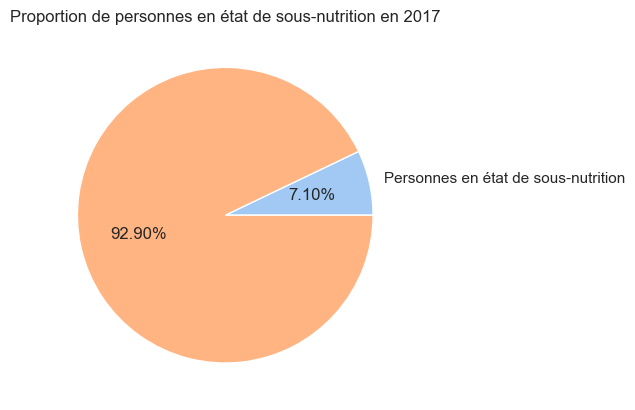

In [63]:
#Calcul et affichage du nombre de personnes en état de sous nutrition
#Calcul de la population totale
population_total = pop_sous_nutrition_2017['Population'].sum()
print(f"La somme totale de la population est : {population_total:,.0f}".replace(",", " "))
#Calcule du nombre de personnes en sous-nutrition
sous_nutrition_total = pop_sous_nutrition_2017['sous_nutrition'].sum()
print(f"Le nombre de personnes dans le monde en sous-nutrition est : {sous_nutrition_total:,.0f}".replace(",", " "))
#Calcul du pourcentage
proportion_sous_nutrition = sous_nutrition_total / population_total *100
print(f"Le pourcentage de personnes dans le monde en sous-nutrition est de : {proportion_sous_nutrition:.2f}")
#Graphique
sous_nutrition_pie = [sous_nutrition_total, (population_total - sous_nutrition_total)]
sns.set_palette('pastel')
plt.pie(sous_nutrition_pie, autopct='%.2f%%', labels=['Personnes en état de sous-nutrition', ''])

plt.title('Proportion de personnes en état de sous-nutrition en 2017')

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.2 - Nombre théorique de personne qui pourrait être nourries</h3>
</div>

In [33]:
#Combien mange en moyenne un être humain ? Source => OMS 
besoin_moyen = 2100

In [34]:
#On commence par faire une jointure entre le data frame population et Dispo_alimentaire afin d'ajouter dans ce dernier la population
pop_dispo_alimentaire_2017 = pd.merge(population_2017, dispo_alimentaire, on='Zone')


In [35]:
#Affichage du nouveau dataframe
pop_dispo_alimentaire_2017.head()

,Zone,Année,Population,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,2017,36296113.0,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53000000.0,0.0,0.0,53000000.0,0.0,53000000.0,0.0,0.0,0.0
1,Afghanistan,2017,36296113.0,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000000.0,2000000.0,40000000.0,39000000.0,2000000.0,3000000.0,0.0,0.0,0.0
2,Afghanistan,2017,36296113.0,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000000.0,0.0,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0
3,Afghanistan,2017,36296113.0,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Afghanistan,2017,36296113.0,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000000.0,0.0,82000000.0,82000000.0,0.0,0.0,0.0,0.0,0.0


In [36]:
#Création de la colonne dispo_kcal avec calcul des kcal disponibles mondialement
pop_dispo_alimentaire_2017['dispo_kcal'] = pop_dispo_alimentaire_2017['Population'] * pop_dispo_alimentaire_2017['Disponibilité alimentaire (Kcal/personne/jour)'] * 365
pop_dispo_alimentaire_2017.head()
dispo_alimentaire_mondiale = np.sum(pop_dispo_alimentaire_2017['dispo_kcal'])
print(dispo_alimentaire_mondiale)

7635429388975815.0


In [ ]:
#Calcul du nombre d'humains pouvant être nourris
nb_humains_nourissables = round(dispo_alimentaire_mondiale / (besoin_moyen * 365)) 
print(f"Le nombre d'humains pouvant être nourris est de : {nb_humains_nourissables:,.0f} ".replace(",", " ") )

#Calcul du pourcentage d'humains nourrissables avec la production actuelle
prop_humains_nourrisssables = round(nb_humains_nourissables / population_total * 100, 2)
print(f"Le pourcentage d'humains nourrissables est de : {prop_humains_nourrisssables}")

Le nombre d'humains pouvant être nourris est de : 9 961 421 251 
Le pourcentage d'humains nourrissables est de : 132.05


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.3 - Nombre théorique de personne qui pourrait être nourrie avec les produits végétaux</h3>
</div>

In [38]:
#Transfert des données avec les végétaux dans un nouveau dataframe
pop_dispo_alimentaire_2017_vegetaux = pop_dispo_alimentaire_2017[pop_dispo_alimentaire_2017['Origine'] == 'vegetale']
pop_dispo_alimentaire_2017_vegetaux.head()

,Zone,Année,Population,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),...,Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,dispo_kcal
1,Afghanistan,2017,36296113.0,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,...,41000000.0,2000000.0,40000000.0,39000000.0,2000000.0,3000000.0,0.0,0.0,0.0,1.324808e+10
2,Afghanistan,2017,36296113.0,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,...,2000000.0,0.0,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0,1.324808e+10
3,Afghanistan,2017,36296113.0,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00
4,Afghanistan,2017,36296113.0,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,...,82000000.0,0.0,82000000.0,82000000.0,0.0,0.0,0.0,0.0,0.0,5.299232e+10
6,Afghanistan,2017,36296113.0,Bière,vegetale,0.0,0.0,0.0,0.09,0.00,...,3000000.0,0.0,3000000.0,3000000.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00


In [39]:
#Calcul du nombre de kcal disponible pour les végétaux
dispo_alimentaire_vegetale = np.sum(pop_dispo_alimentaire_2017_vegetaux['dispo_kcal'])
print(dispo_alimentaire_vegetale)

6300178937197865.0


In [66]:
#Calcul du nombre d'humains pouvant être nourris avec les végétaux
nb_humains_nourissables_vegetaux = round(dispo_alimentaire_vegetale/ (besoin_moyen*365))
print(f"Le nombre d'humains pouvant être nourris avec les végétaux est de : {nb_humains_nourissables_vegetaux:,.0f} ".replace(",", " ") )

#Calcul du pourcentage d'humains nourrissables avec la production actuelle de végétaux
prop_humains_nourrisssables = round(nb_humains_nourissables_vegetaux / population_total * 100, 2)
print(f"Le pourcentage d'humains nourrissables avec les végétaux est de : {prop_humains_nourrisssables}")

Le nombre d'humains pouvant être nourris avec les végétaux est de : 8 219 411 529 
Le pourcentage d'humains nourrissables avec les végétaux est de : 108.96


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.4 - Utilisation de la disponibilité intérieure</h3>
</div>

In [41]:
#Calcul de la disponibilité totale
dispo_totale = np.sum(pop_dispo_alimentaire_2017['Disponibilité intérieure'])
print(dispo_totale)

9733927000000.0


Quantité d'aliments utilisée par la catégorie Semences : 153 317 000 000
Quantité d'aliments utilisée par la catégorie Aliments pour animaux : 1 288 002 000 000
Quantité d'aliments utilisée par la catégorie Nourriture : 4 805 525 000 000
Quantité d'aliments utilisée par la catégorie Pertes : 452 283 000 000
Quantité d'aliments utilisée par la catégorie Traitement : 2 185 641 000 000
Quantité d'aliments utilisée par la catégorie Autres Utilisations : 858 771 000 000
[153317000000.0, 1288002000000.0, 4805525000000.0, 452283000000.0, 2185641000000.0, 858771000000.0]
Production : 9 921 364 000 000
Exportations - Quantité : 1 331 999 000 000
Importations - Quantité : 1 247 345 000 000
Variation de stock : -102 605 000 000


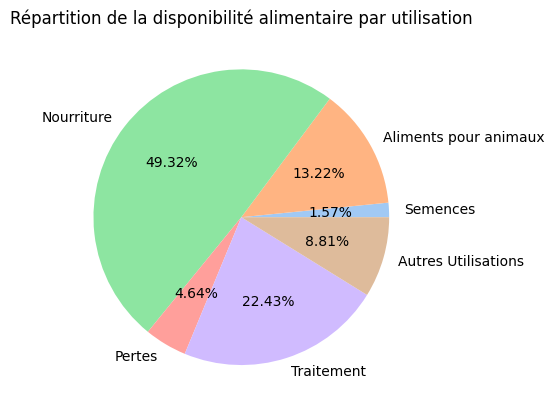

In [42]:
#création d'une boucle for pour afficher les différentes valeurs en fonction des colonnes aliments pour animaux, pertes, nourritures, 
utilisations = ['Semences','Aliments pour animaux', 'Nourriture', 'Pertes','Traitement', 'Autres Utilisations']
#Création d'une liste pour stocker les résultats par utilisation
utilisations_prop = []
#Graphique et affichage des données
sns.set_palette('pastel')
for i in utilisations : 
    print(f"Quantité d'aliments utilisée par la catégorie {i} : {np.sum(pop_dispo_alimentaire_2017[i]):,.0f}".replace(",", " "))
    utilisations_prop.append(np.sum(pop_dispo_alimentaire_2017[i]))
print(utilisations_prop,)
plt.pie(utilisations_prop, autopct='%.2f%%', labels=utilisations)
plt.title('Répartition de la disponibilité alimentaire par utilisation')
dispo_provenance = ['Production','Exportations - Quantité', 'Importations - Quantité', 'Variation de stock']
for i in dispo_provenance : 
    print(f"{i} : {np.sum(pop_dispo_alimentaire_2017[i]):,.0f}".replace(",", " "))

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.5 - Utilisation des céréales</h3>
</div>

In [43]:
#Création d'une liste avec toutes les variables
cereales = ['Blé', 'Riz (Eq Blanchi)', 'Orge', 'Maïs', 'Seigle', 'Avoine', 'Millet', 'Sorgho', 'Céréales, Autres']

In [44]:
#Création d'un dataframe avec les informations uniquement pour ces céréales
dispo_alimentaire_cereales = pop_dispo_alimentaire_2017[(pop_dispo_alimentaire_2017['Produit'].isin(cereales)) ]
dispo_alimentaire_cereales.head(15)

,Zone,Année,Population,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),...,Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,dispo_kcal
7,Afghanistan,2017,36296113.0,Blé,vegetale,0.000000e+00,0.0,1369.0,160.23,4.69,...,5.992000e+09,0.000000e+00,1.173000e+09,4.895000e+09,775000000.0,5.169000e+09,322000000.0,0.0,-3.500000e+08,1.813662e+13
12,Afghanistan,2017,36296113.0,"Céréales, Autres",vegetale,0.000000e+00,0.0,0.0,0.00,0.00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00
32,Afghanistan,2017,36296113.0,Maïs,vegetale,2.000000e+08,0.0,21.0,2.50,0.30,...,3.130000e+08,0.000000e+00,1.000000e+06,7.600000e+07,31000000.0,3.120000e+08,5000000.0,0.0,0.000000e+00,2.782097e+11
34,Afghanistan,2017,36296113.0,Millet,vegetale,0.000000e+00,0.0,3.0,0.40,0.02,...,1.300000e+07,0.000000e+00,0.000000e+00,1.200000e+07,1000000.0,1.300000e+07,0.0,0.0,0.000000e+00,3.974424e+10
40,Afghanistan,2017,36296113.0,Orge,vegetale,3.600000e+08,0.0,26.0,2.92,0.24,...,5.240000e+08,0.000000e+00,1.000000e+07,8.900000e+07,52000000.0,5.140000e+08,22000000.0,0.0,0.000000e+00,3.444501e+11
47,Afghanistan,2017,36296113.0,Riz (Eq Blanchi),vegetale,0.000000e+00,0.0,141.0,13.82,0.27,...,4.610000e+08,0.000000e+00,1.190000e+08,4.220000e+08,24000000.0,3.420000e+08,14000000.0,0.0,0.000000e+00,1.867979e+12
67,Afrique du Sud,2017,57009756.0,Avoine,vegetale,8.000000e+06,0.0,5.0,0.75,0.09,...,4.900000e+07,4.000000e+06,2.500000e+07,4.000000e+07,1000000.0,2.800000e+07,1000000.0,0.0,0.000000e+00,1.040428e+11
72,Afrique du Sud,2017,57009756.0,Blé,vegetale,3.700000e+07,0.0,492.0,60.13,2.09,...,3.316000e+09,4.950000e+08,1.490000e+09,3.174000e+09,74000000.0,1.870000e+09,31000000.0,0.0,4.500000e+08,1.023781e+13
81,Afrique du Sud,2017,57009756.0,"Céréales, Autres",vegetale,8.000000e+06,0.0,1.0,0.07,0.00,...,1.200000e+07,1.000000e+07,3.000000e+06,4.000000e+06,0.0,1.900000e+07,0.0,0.0,0.000000e+00,2.080856e+10
111,Afrique du Sud,2017,57009756.0,Maïs,vegetale,4.715000e+09,0.0,858.0,100.10,7.69,...,1.048000e+10,3.036000e+09,5.600000e+07,5.283000e+09,405000000.0,1.181100e+10,33000000.0,43000000.0,1.650000e+09,1.785375e+13


In [45]:
#Affichage de la proportion d'alimentation animale
dispo_interieure_cereale = np.sum(dispo_alimentaire_cereales['Disponibilité intérieure'])
dispo_interieure_cereale_alim_animale = np.sum(dispo_alimentaire_cereales['Aliments pour animaux'])
proportion_alim_animale_cereale = round(dispo_interieure_cereale_alim_animale/dispo_interieure_cereale*100, 2)
print(proportion_alim_animale_cereale)
dispo_alim_par_cereale_alim_animale = dispo_alimentaire_cereales.groupby('Produit')['Aliments pour animaux'].sum().reset_index()


36.14


42.91


Text(0, 0.5, 'Quantité (en centaine de milliards de kg)')

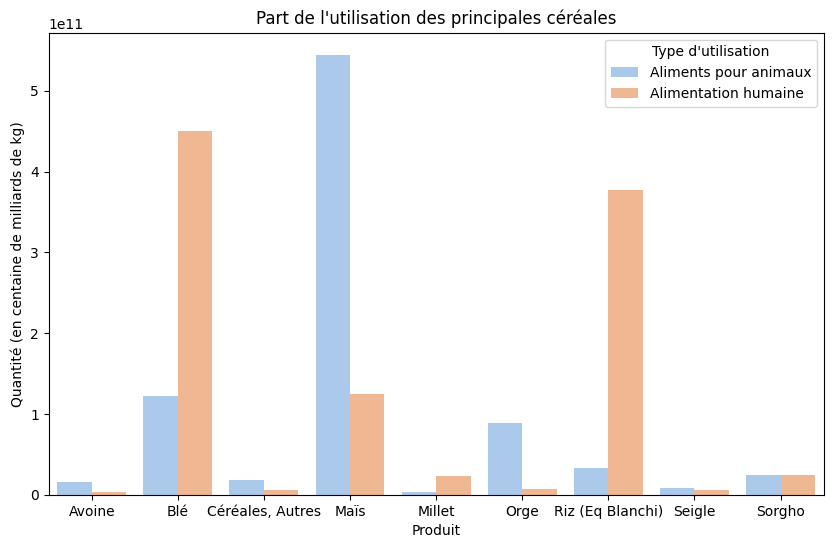

In [46]:
#Affichage de la proportion d'alimentation humaine
dispo_interieure_cereale_alim_humaine = np.sum(dispo_alimentaire_cereales['Nourriture'])
proportion_alim_humaine_cereale = round(dispo_interieure_cereale_alim_humaine/dispo_interieure_cereale*100, 2)
print(proportion_alim_humaine_cereale)
dispo_alim_par_cereale_alim_humaine = dispo_alimentaire_cereales.groupby('Produit')['Nourriture'].sum().reset_index()

dispo_alim_par_cereale_alim_humaine['Type d\'utilisation'] = 'Alimentation humaine'
dispo_alim_par_cereale_alim_humaine = dispo_alim_par_cereale_alim_humaine.rename(columns={'Nourriture': 'Valeur'})
dispo_alim_par_cereale_alim_animale['Type d\'utilisation'] = 'Aliments pour animaux'
dispo_alim_par_cereale_alim_animale = dispo_alim_par_cereale_alim_animale.rename(columns={'Aliments pour animaux': 'Valeur'})

#Création d'un dataframe regroupant les données pour l'alimentation humaine et l'alimentation animale
dispo_alim_par_cereale_humain_animaux = pd.concat([dispo_alim_par_cereale_alim_animale, dispo_alim_par_cereale_alim_humaine], ignore_index=True)

#Graphique
plt.figure(figsize=(10,6))
sns.set_palette('pastel')
sns.barplot(data=dispo_alim_par_cereale_humain_animaux, x='Produit', y='Valeur', hue='Type d\'utilisation')
plt.title('Part de l\'utilisation des principales céréales')
plt.ylabel('Quantité (en centaine de milliards de kg)')





<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.6 - Pays avec la proportion de personnes sous-alimentée la plus forte en 2017</h3>
</div>

In [47]:
#Création de la colonne proportion par pays
pop_sous_nutrition_2017 = pop_sous_nutrition_2017.copy()
pop_sous_nutrition_2017['Proportion de personnes en sous-nutrition'] = round(pop_sous_nutrition_2017['sous_nutrition']/pop_sous_nutrition_2017['Population']*100, 2)
pop_sous_nutrition_2017.head()

,Zone,Année_x,Population,Année_y,sous_nutrition,Proportion de personnes en sous-nutrition
0,Afghanistan,2017,36296113.0,2016-2018,10500000.0,28.93
1,Afrique du Sud,2017,57009756.0,2016-2018,3100000.0,5.44
2,Albanie,2017,2884169.0,2016-2018,100000.0,3.47
3,Algérie,2017,41389189.0,2016-2018,1300000.0,3.14
4,Allemagne,2017,82658409.0,2016-2018,0.0,0.00


Text(0, 0.5, '')

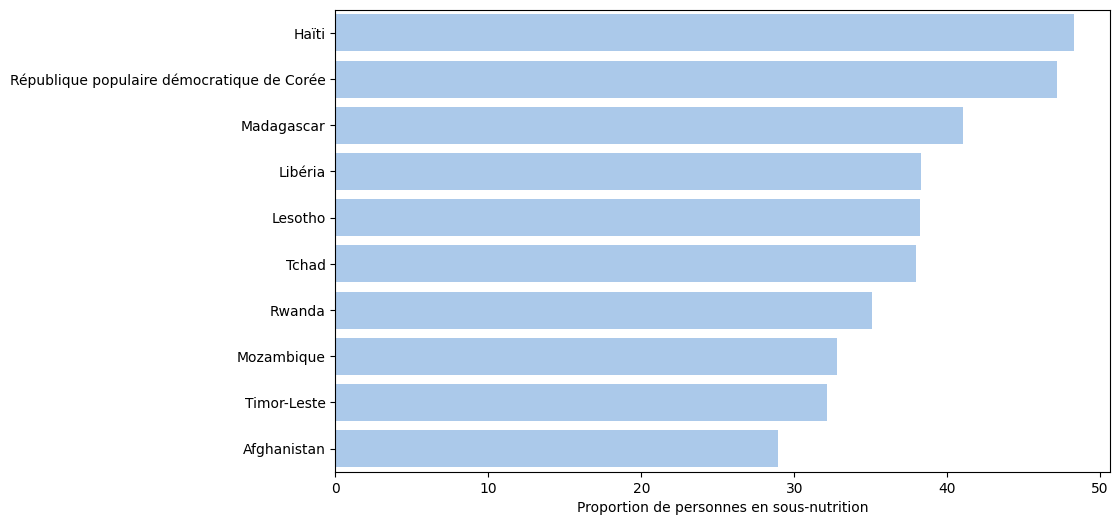

In [48]:
#affichage après tri des 10 pires pays
#Tri du dataframe dans l'ordre décroissant
pop_sous_nutrition_2017_top10 =  pop_sous_nutrition_2017.sort_values('Proportion de personnes en sous-nutrition', ascending=False)
pop_sous_nutrition_2017_top10.head(10)

#Cration d'un dataframe pour les 10 premières valeurs
pop_sous_nutrition_2017_top10_df = pop_sous_nutrition_2017_top10[:10]
pop_sous_nutrition_2017_top10.head

#Graphique
plt.figure(figsize=(10, 6))
sns.barplot(pop_sous_nutrition_2017_top10_df, x='Proportion de personnes en sous-nutrition', y='Zone')
plt.ylabel('')

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.7 - Pays qui ont le plus bénéficié d'aide alimentaire depuis 2013</h3>
</div>

In [49]:
#calcul du total de l'aide alimentaire par pays
aide_alimentaire_par_pays = aide_alimentaire.groupby('Zone')['Valeur'].sum()
aide_alimentaire_par_pays.head()

Zone
Afghanistan    185452000
Algérie         81114000
Angola           5014000
Bangladesh     348188000
Bhoutan          2666000
Name: Valeur, dtype: int64

Text(0.5, 0, 'Quantité (en milliard de kg)')

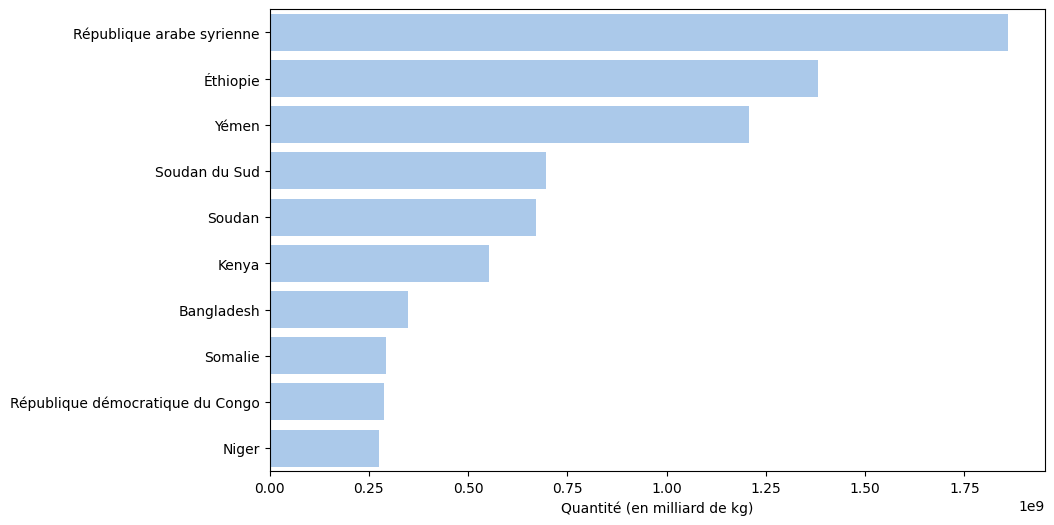

In [ ]:
#affichage après tri des 10 pays qui ont bénéficié le plus de l'aide alimentaire
#Tri du dataframe dans l'ordre décroissant
aide_alimentaire_par_pays_sorted = aide_alimentaire_par_pays.sort_values(ascending=False).reset_index()

#Cration d'un dataframe pour les 10 premières valeurs
aide_alimentaire_par_pays_top10 = aide_alimentaire_par_pays_sorted[:10]

#Graphique
plt.figure(figsize=(10, 6))
sns.barplot(aide_alimentaire_par_pays_top10, x='Valeur', y='Zone')
plt.ylabel('')
plt.xlabel('Quantité (en milliard de kg)')

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.8 - Evolution des 5 pays qui ont le plus bénéficiés de l'aide alimentaire entre 2013 et 2016</h3>
</div>

In [51]:
#Création d'un dataframe avec la zone, l'année et l'aide alimentaire puis groupby sur zone et année 
aide_alimentaire_partiel = aide_alimentaire[['Zone', 'Année', 'Valeur']].copy()
aide_alimentaire_partiel = aide_alimentaire_partiel.groupby(['Zone', 'Année']).sum()
aide_alimentaire_partiel.head(40)

Valeur
Zone                            Année           
Afghanistan                     2013   128238000
                                2014    57214000
Algérie                         2013    35234000
                                2014    18980000
                                2015    17424000
                                2016     9476000
Angola                          2013     5000000
                                2014       14000
Bangladesh                      2013   131018000
                                2014   194628000
                                2015    22542000
Bhoutan                         2013     1724000
                                2014      146000
                                2015      578000
                                2016      218000
Bolivie (État plurinational de) 2014        6000
Burkina Faso                    2013    18620000
                                2014    22938000
                                2015    23182000
                                2016       72000
Burundi                         2013    53372000
                                2014    11010000
                                2015    12936000
Bénin                           2013    17622000
                                2014      672000
                                2015     3786000
                                2016      144000
Cambodge                        2013    10974000
                                2014    12072000
                                2015     2734000
Cameroun                        2013     4906000
                                2014    13684000
                                2015    32310000
                                2016      578000
Chine, continentale             2014     1298000
Colombie                        2013    11442000
                                2014     9196000
                                2015     6642000
                                2016     5466000
Comores                         2013     7806000

In [52]:
#Création d'une liste contenant les 5 pays qui ont le plus bénéficié de l'aide alimentaire
aide_alimentaire_par_pays_top10 = aide_alimentaire_par_pays_top10.set_index('Zone')
liste_aide_alim_top5 = aide_alimentaire_par_pays_top10[:5].index.tolist()
print(liste_aide_alim_top5)

['République arabe syrienne', 'Éthiopie', 'Yémen', 'Soudan du Sud', 'Soudan']


In [53]:
#On filtre sur le dataframe avec notre liste
aide_alimentaire_partiel = aide_alimentaire_partiel.reset_index()
aide_alimentaire_partiel_top5 = aide_alimentaire_partiel[aide_alimentaire_partiel['Zone'].isin(liste_aide_alim_top5)].copy()
aide_alimentaire_partiel_top5.head()


,Zone,Année,Valeur
157,République arabe syrienne,2013,563566000
158,République arabe syrienne,2014,651870000
159,République arabe syrienne,2015,524949000
160,République arabe syrienne,2016,118558000
189,Soudan,2013,330230000


Text(0, 0.5, 'Quantité (en centaine de millions de kg)')

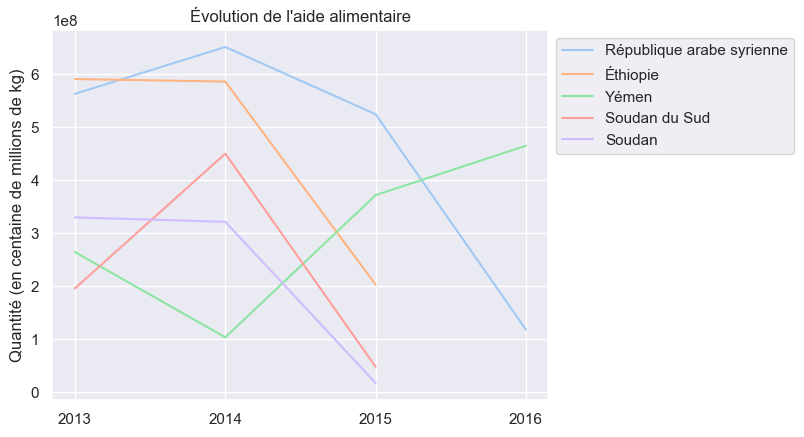

In [64]:
# Affichage des pays avec l'aide alimentaire par année
sns.set_theme(palette='pastel')
plt.title('Évolution de l\'aide alimentaire')
for zone in liste_aide_alim_top5:
    data = aide_alimentaire_partiel_top5[aide_alimentaire_partiel_top5['Zone'] == zone]
    data.reset_index()
    plt.plot(data['Année'], data['Valeur'])
    plt.legend(liste_aide_alim_top5,bbox_to_anchor=(1, 1), loc='upper left')
plt.xticks([2013, 2014, 2015, 2016])
plt.ylabel('Quantité (en centaine de millions de kg)')


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.9 - Pays avec le moins de disponibilité par habitant</h3>
</div>

In [55]:
#Calcul de la disponibilité en kcal par personne par jour par pays
dispo_alimentaire_par_pays_2017 = pop_dispo_alimentaire_2017.groupby('Zone')['Disponibilité alimentaire (Kcal/personne/jour)'].sum()
dispo_alimentaire_par_pays_2017.head()

Zone
Afghanistan       2087.0
Afrique du Sud    3020.0
Albanie           3188.0
Algérie           3293.0
Allemagne         3503.0
Name: Disponibilité alimentaire (Kcal/personne/jour), dtype: float64

In [ ]:
#Affichage des 10 pays qui ont le moins de dispo alimentaire par personne 
#Tri du dataframe dans l'ordre croissant
dispo_alimentaire_par_pays_2017_bottom10 = dispo_alimentaire_par_pays_2017.sort_values()
dispo_alimentaire_par_pays_2017_bottom10.head(10)

Zone
République centrafricaine                     1879.0
Zambie                                        1924.0
Madagascar                                    2056.0
Afghanistan                                   2087.0
Haïti                                         2089.0
République populaire démocratique de Corée    2093.0
Tchad                                         2109.0
Zimbabwe                                      2113.0
Ouganda                                       2126.0
Timor-Leste                                   2129.0
Name: Disponibilité alimentaire (Kcal/personne/jour), dtype: float64

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.10 - Pays avec le plus de disponibilité par habitant</h3>
</div>

In [ ]:
#Affichage des 10 pays qui ont le plus de dispo alimentaire par personne 
#Tri du dataframe dans l'ordre décroissant
dispo_alimentaire_par_pays_2017_top10 = dispo_alimentaire_par_pays_2017.sort_values(ascending=False)
dispo_alimentaire_par_pays_2017_top10.head(10)

Zone
Autriche                 3770.0
Belgique                 3737.0
Turquie                  3708.0
États-Unis d'Amérique    3682.0
Israël                   3610.0
Irlande                  3602.0
Italie                   3578.0
Luxembourg               3540.0
Égypte                   3518.0
Allemagne                3503.0
Name: Disponibilité alimentaire (Kcal/personne/jour), dtype: float64

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.11 - Exemple de la Thaïlande pour le Manioc</h3>
</div>

In [58]:
#création d'un dataframe avec uniquement la Thaïlande 
dispo_alimentaire_thailande = pop_dispo_alimentaire_2017[pop_dispo_alimentaire_2017['Zone'] == 'Thaïlande'].copy()
sous_nutrition_thailande = pop_sous_nutrition_2017[pop_sous_nutrition_2017['Zone'] == 'Thaïlande'].copy()
dispo_alimentaire_thailande_manioc = dispo_alimentaire_thailande[dispo_alimentaire_thailande['Produit'] == 'Manioc'] 


In [ ]:
#Calcul de la sous nutrition en Thaïlande
#Calcul du nombre de personne en sous-nutrition en Thaïlande
nb_personnes_sous_nutrition_thailande = sous_nutrition_thailande['sous_nutrition'].iloc[0]
print(f"Le nombre de personne en état de sous-nutrition en Thaïlande est de {nb_personnes_sous_nutrition_thailande:,.0f}".replace(","," "))

# Part des personnes en sous-nutrition en Thaïlande
proportion_sous_nutrition_thailande = round(nb_personnes_sous_nutrition_thailande/sous_nutrition_thailande['Population']*100, 2)
print(f"La proportion de personnes en état de sous-nutrition en Thaïlande est de {proportion_sous_nutrition_thailande.iloc[0]} %& &")

#Calcul du nombre de personnes pouvant être nourris avec le manioc restant en Thaïlande
total_kcal_jour_manioc = dispo_alimentaire_thailande_manioc['dispo_kcal'].iloc[0] /365
nb_personnes_nourrissables_manioc = total_kcal_jour_manioc / besoin_moyen
print(f"Le nombre de personnes nourrissables avec le manioc restant en Thaïlande est de {nb_personnes_nourrissables_manioc:,.0f}".replace(",", " "))

#Calcul du pourcentage de manioc exporté de Thaïlande
proportion_manioc_exporté_thailande = round(dispo_alimentaire_thailande_manioc['Exportations - Quantité'].iloc[0]/dispo_alimentaire_thailande_manioc['Production'].iloc[0]*100,2)
print(f"La proportion du manioc exporté de Thaïlande est de {proportion_manioc_exporté_thailande} %")

# Calcul du ratio calorique du Manioc en Thaïlande (Kcal par Kg)
ratio_kcal_kg = dispo_alimentaire_thailande_manioc['dispo_kcal'].iloc[0] / (dispo_alimentaire_thailande_manioc['Disponibilité intérieure'].iloc[0] * 1_000_000)

# Calcule du total de Kcal exportées
total_kcal_exportees = (dispo_alimentaire_thailande_manioc['Exportations - Quantité'].iloc[0] * 1_000_000) * ratio_kcal_kg

# Calcule du nombre de personnes nourrissables par ces exports
nb_personnes_nourrissables_export = total_kcal_exportees / (besoin_moyen * 365)

print(f"Les exportations de manioc pourraient nourrir {nb_personnes_nourrissables_export:,.0f} personnes".replace(",", " "))

nb_personnes_nourrissables_manioc_total = nb_personnes_nourrissables_manioc + nb_personnes_nourrissables_export
print(f"Avec sa production totale de manioc, la Thaïlande pourrait nourrir {round(nb_personnes_nourrissables_manioc_total):,.0f} personnes.".replace(",", " "))

Le nombre de personne en état de sous-nutrition en Thaïlande est de 6 200 000
La proportion de personnes en état de sous-nutrition en Thaïlande est de 8.96 %& &
Le nombre de personnes nourrissables avec le manioc restant en Thaïlande est de 1 318 282
La proportion du manioc exporté de Thaïlande est de 83.41 %
Les exportations de manioc pourraient nourrir 5 306 380 personnes
Avec sa production totale de manioc  la Thaïlande pourrait nourrir 6 624 662 personnes.


<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 6 - Analyse complémentaires</h2>
</div>

Text(0.5, 1.0, 'Taux de sous-nutrition en fonction de la disponibilité alimentaire')

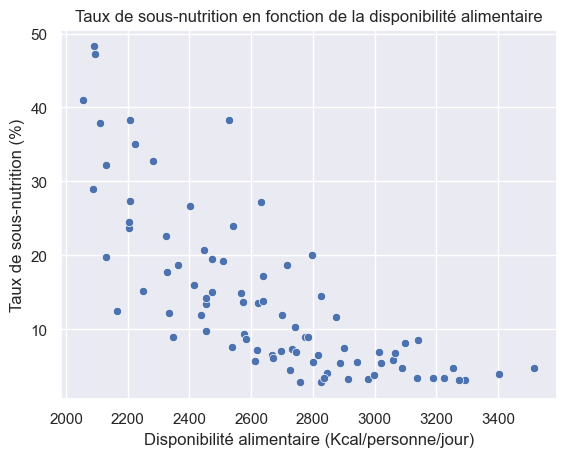

In [60]:
#ajouter en dessous toutes les analyses complémtaires
#Comparaison entre dispo alimentaire et sous-nutrition

pop_sous_nutrition_2017['Pourcentage de la population'] = round(pop_sous_nutrition_2017['sous_nutrition']/pop_sous_nutrition_2017['Population']*100, 2)
dispo_alim_sous_nutrition = pd.merge(dispo_alimentaire_par_pays_2017, pop_sous_nutrition_2017, on='Zone').reset_index()
dispo_alim_sous_nutrition_nettoyee = dispo_alim_sous_nutrition[dispo_alim_sous_nutrition['Pourcentage de la population'] > 0]
sns.scatterplot(dispo_alim_sous_nutrition_nettoyee, x='Disponibilité alimentaire (Kcal/personne/jour)', y='Pourcentage de la population')
plt.ylabel('Taux de sous-nutrition (%)')
plt.title('Taux de sous-nutrition en fonction de la disponibilité alimentaire')
